<a href="https://colab.research.google.com/github/AnjiLakshmi12/6thSem-ML-Lab/blob/main/1BM24CS401_Lab_10_PCA_ipynb%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('/content/heart (1).csv')

# Display the first 5 rows of the dataframe
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Display basic information about the dataset
print("\nInformation about the dataset:")
df.info()


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
# Display descriptive statistics
print("\nDescriptive statistics of the dataset:")
display(df.describe())


Descriptive statistics of the dataset:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Preprocessing: Converting Text Columns to Numbers and Scaling

Based on the `df.info()` output, it appears all columns are already numerical. However, some columns might be categorical in nature (e.g., `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`). I will treat the columns `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal` as categorical and apply one-hot encoding. For the target variable, it is usually already encoded as 0 or 1, if not, I will apply label encoding.

First, let's explicitly identify categorical and numerical columns for proper encoding and scaling.

In [13]:
# Separate features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Identify categorical and numerical columns (adjust based on domain knowledge if needed)
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Apply One-Hot Encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nFeatures after One-Hot Encoding (first 5 rows):")
display(X_encoded.head())

Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Features after One-Hot Encoding (first 5 rows):


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,FastingBS_1
0,40,140,289,172,0.0,True,True,False,False,True,False,False,False,True,False
1,49,160,180,156,1.0,False,False,True,False,True,False,False,True,False,False
2,37,130,283,98,0.0,True,True,False,False,False,True,False,False,True,False
3,48,138,214,108,1.5,False,False,False,False,True,False,True,True,False,False
4,54,150,195,122,0.0,True,False,True,False,True,False,False,False,True,False


In [14]:
# Split the data into training and testing sets before scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Apply Scaling to numerical features
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for easier inspection if needed (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

print("\nScaled Training Features (first 5 rows of DataFrame):")
display(X_train_scaled_df.head())


Scaled Training Features (first 5 rows of DataFrame):


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,FastingBS_1
0,-1.245067,-0.708985,0.372803,2.284353,-0.097061,0.540605,-0.483336,1.879059,-0.213504,0.808179,-0.487621,-0.838461,-1.03325,-0.847921,1.842609
1,-1.886236,-0.166285,0.086146,1.652241,-0.836286,0.540605,-0.483336,1.879059,-0.213504,0.808179,-0.487621,-0.838461,-1.03325,1.179356,-0.542709
2,0.250993,0.919115,0.123134,-0.441628,0.087745,0.540605,-0.483336,-0.532181,-0.213504,0.808179,-0.487621,1.192662,0.96782,-0.847921,1.842609
3,-1.779375,-0.166285,0.104640,0.229991,-0.836286,-1.849780,-0.483336,1.879059,-0.213504,0.808179,-0.487621,-0.838461,-1.03325,1.179356,-0.542709
4,-0.283314,-0.708985,-1.846478,-1.271274,-0.836286,0.540605,-0.483336,-0.532181,-0.213504,0.808179,-0.487621,-0.838461,0.96782,-0.847921,1.842609


### Build Classification Models and Check Accuracy (without PCA)

Now, I will build and evaluate the classification models (Logistic Regression, SVM, Random Forest) using the scaled data.

In [15]:
# Initialize models
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
svm_model = SVC(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

models = {
    'Logistic Regression': logistic_model,
    'SVM': svm_model,
    'Random Forest': rf_model
}

accuracy_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

# Find the best performing model
best_model_name = max(accuracy_results, key=accuracy_results.get)
print(f"\nModel without PCA with the best accuracy: {best_model_name} (Accuracy: {accuracy_results[best_model_name]:.4f})")


Training Logistic Regression...
Logistic Regression Accuracy: 0.8533

Training SVM...
SVM Accuracy: 0.8750

Training Random Forest...
Random Forest Accuracy: 0.8587

Model without PCA with the best accuracy: SVM (Accuracy: 0.8750)


### Apply PCA to Reduce Dimensions, Retrain Models, and Check Impact on Accuracy

Now, I will apply PCA to reduce the dimensionality of the scaled data, and then retrain and evaluate the same classification models.

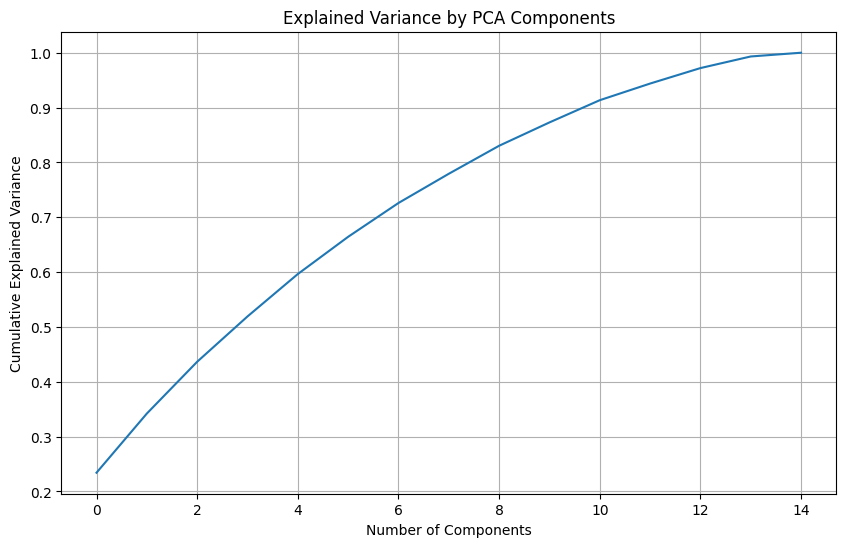

Original number of features: 15
Reduced number of features after PCA: 10


In [16]:
# Determine optimal number of components for PCA (optional but good practice)
pca_test = PCA().fit(X_train_scaled)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Based on the plot, choose a number of components that explains a significant amount of variance.
# For demonstration, let's choose N components (e.g., 95% of variance or a fixed number).
# Let's try 10 components or 95% variance (you can adjust this after seeing the plot)
# For this dataset, let's use a fixed number of components, say, 10 for demonstration.
n_components = 10 # This can be adjusted based on the cumulative explained variance plot
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Reduced number of features after PCA: {X_train_pca.shape[1]}")

In [17]:
# Retrain models with PCA-transformed data
accuracy_results_pca = {}

for name, model in models.items(): # Use the same initialized models
    print(f"\nTraining {name} with PCA data...")
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test, y_pred_pca)
    accuracy_results_pca[name] = accuracy_pca
    print(f"{name} Accuracy (with PCA): {accuracy_pca:.4f}")

# Find the best performing model with PCA
best_model_pca_name = max(accuracy_results_pca, key=accuracy_results_pca.get)
print(f"\nModel with PCA with the best accuracy: {best_model_pca_name} (Accuracy: {accuracy_results_pca[best_model_pca_name]:.4f})")


Training Logistic Regression with PCA data...
Logistic Regression Accuracy (with PCA): 0.8533

Training SVM with PCA data...
SVM Accuracy (with PCA): 0.8750

Training Random Forest with PCA data...
Random Forest Accuracy (with PCA): 0.8696

Model with PCA with the best accuracy: SVM (Accuracy: 0.8750)


### Comparison of Model Accuracies (Before and After PCA)

Let's compare the accuracies side-by-side.

In [18]:
comparison_df = pd.DataFrame({
    'Model': list(accuracy_results.keys()),
    'Accuracy (Without PCA)': list(accuracy_results.values()),
    'Accuracy (With PCA)': list(accuracy_results_pca.values())
})

print("\nAccuracy Comparison:")
display(comparison_df)

print("\nImpact of PCA on model accuracy:")
for name in accuracy_results.keys():
    diff = accuracy_results_pca[name] - accuracy_results[name]
    if diff > 0:
        print(f"{name}: Accuracy increased by {diff:.4f}")
    elif diff < 0:
        print(f"{name}: Accuracy decreased by {abs(diff):.4f}")
    else:
        print(f"{name}: Accuracy remained the same")


Accuracy Comparison:


,Model,Accuracy (Without PCA),Accuracy (With PCA)
0,Logistic Regression,0.853261,0.853261
1,SVM,0.875000,0.875000
2,Random Forest,0.858696,0.869565



Impact of PCA on model accuracy:
Logistic Regression: Accuracy remained the same
SVM: Accuracy remained the same
Random Forest: Accuracy increased by 0.0109
